# 导入依赖

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.4)
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import nbformat

# 预处理

## 将数据集恢复为训练和测试

In [12]:
X = pd.read_csv('train_clean.csv')
X_test = pd.read_csv('test_clean.csv')
y = pd.read_csv('train.csv')['Transported']

## 丢弃不需要的属性

In [13]:
X.drop(['PassengerId', 'Group', 'Group_size', 'Cabin_number'], axis=1, inplace=True)
X_test.drop(['PassengerId', 'Group', 'Group_size', 'Cabin_number'], axis=1, inplace=True)

## 对支出特征进行对数变换
对数变换用于减少分布中的偏斜，尤其是大的离群值。 它可以使算法更容易 "学习 "正确的关系。 我们将对支出特征进行对数变换，因为这些特征因异常值而严重偏斜。

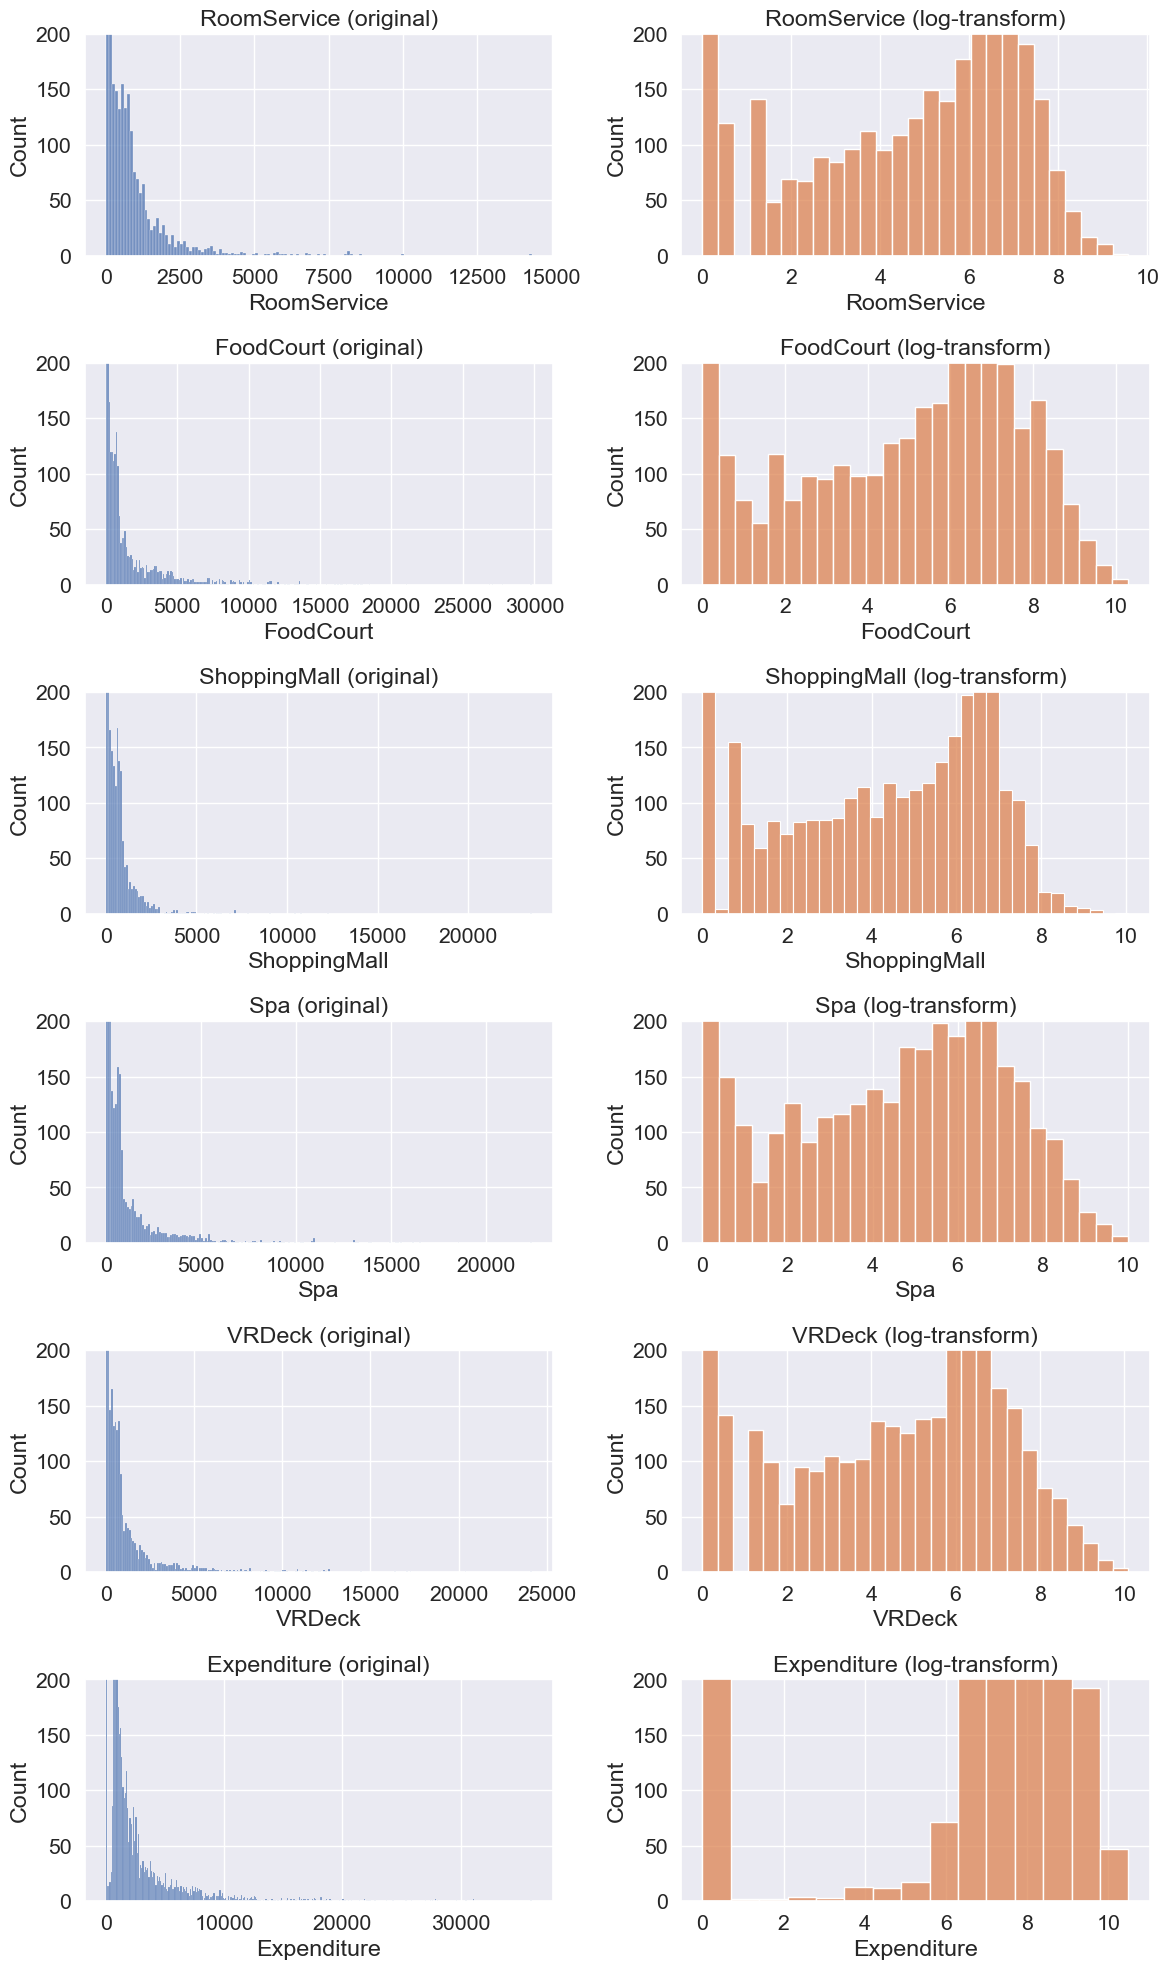

In [14]:
# Plot log transform results
fig = plt.figure(figsize=(12, 20))
for i, col in enumerate(['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Expenditure']):
    plt.subplot(6, 2, 2 * i + 1)
    sns.histplot(X[col], binwidth=100)
    plt.ylim([0, 200])
    plt.title(f'{col} (original)')

    plt.subplot(6, 2, 2 * i + 2)
    sns.histplot(np.log(1 + X[col]), color='C1')
    plt.ylim([0, 200])
    plt.title(f'{col} (log-transform)')

fig.tight_layout()
plt.show()

可见原始数据的偏斜都很严重，进行对数变换后分布明显更加均匀。

In [15]:
# 应用对数变换
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Expenditure']:
    X[col] = np.log(1 + X[col])
    X_test[col] = np.log(1 + X_test[col])

## 缩放和编码
使用column transformers

In [16]:
# 区分数值特征和分类特征
numerical_cols = [cname for cname in X.columns if X[cname].dtype in ['int64', 'float64']]
categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]

# 数值特征标准化
numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# 分类特征使用One-Hot 编码：为每个分类特征的每个可能值创建一个新的二进制特征
categorical_transformer = Pipeline(
    steps=[('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))])

# 合并为一个transformer
ct = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)],
    remainder='passthrough')

# 应用transformer
X = ct.fit_transform(X)
X_test = ct.transform(X_test)

# 显示处理后数据集形状
print('Training set shape:', X.shape)

Training set shape: (8693, 37)


## PCA
通过主成分分析（PCA）降维，将原始数据集降维到3维，大致观察下分布情况。

In [17]:
pca = PCA(n_components=3)
components = pca.fit_transform(X)

total_var = pca.explained_variance_ratio_.sum() * 100

fig = px.scatter_3d(
    components, x=0, y=1, z=2, color=y, size=0.1 * np.ones(len(X)), opacity=1,
    title=f'Total Explained Variance: {total_var:.2f}%',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'},
    width=800, height=500
)
fig.show()

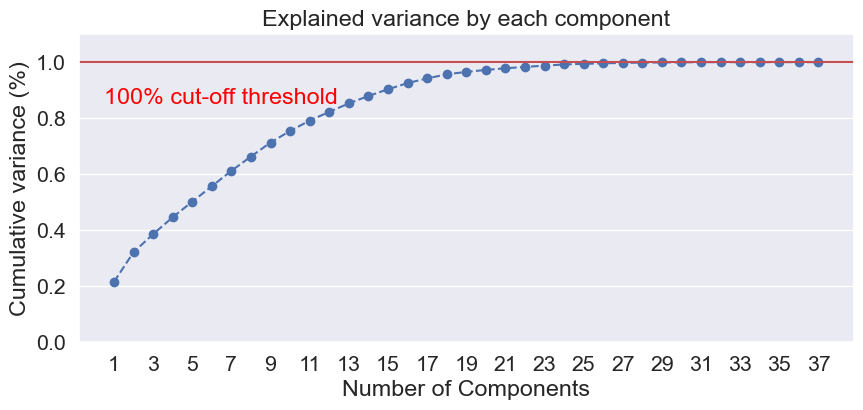

In [18]:
# 解释方差
pca = PCA().fit(X)
fig, ax = plt.subplots(figsize=(10, 4))
xi = np.arange(1, 1 + X.shape[1], step=1)
yi = np.cumsum(pca.explained_variance_ratio_)
plt.plot(xi, yi, marker='o', linestyle='--', color='b')

# 美化
plt.ylim(0.0, 1.1)
plt.xlabel('Number of Components')
plt.xticks(np.arange(1, 1 + X.shape[1], step=2))
plt.ylabel('Cumulative variance (%)')
plt.title('Explained variance by each component')
plt.axhline(y=1, color='r', linestyle='-')
plt.text(0.5, 0.85, '100% cut-off threshold', color='red')
ax.grid(axis='x')

**存储处理后的数据**

In [19]:
np.save('X_test.npy', X_test)
np.save('X.npy', X)
np.save("y.npy", y)

In [20]:
assert X.shape[0] == y.shape[0], "特征和标签的样本数不匹配！"